In [1]:
!pip install nba_api

In [2]:
!conda install -c conda-forge nba_api -y

Jupyter detected...
2 channel Terms of Service accepted
Channels:
 - conda-forge
 - defaults
Platform: osx-arm64
Solving environment: failed

PackagesNotFoundError: The following packages are not available from current channels:

  - nba_api

Current channels:

  - https://conda.anaconda.org/conda-forge
  - defaults

To search for alternate channels that may provide the conda package you're
looking for, navigate to

    https://anaconda.org

and use the search bar at the top of the page.




In [3]:
# 📦 IMPORT MODULES

import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
from nba_api.stats.endpoints import leaguegamefinder
from datetime import datetime
from sklearn.linear_model import LinearRegression
from mpl_toolkits.mplot3d import Axes3D

plt.style.use("seaborn-v0_8")

In [4]:
# 🌐 API CLIENT

class ApiClient:
    
    def __init__(self, season='2023-24'):
        self.season = season
        
    def fetch_games(self):
        games = leaguegamefinder.LeagueGameFinder(
            season_nullable=self.season,
            league_id_nullable='00'
        )
        
        df = games.get_data_frames()[0]
        
        return df

In [5]:
# 🏀 GAME OBJECT

class Game:
    
    def __init__(self, row):
        self.date = pd.to_datetime(row['GAME_DATE'])
        self.matchup = row['MATCHUP']
        self.points = row['PTS']
        self.win = row['WL']
        
        self.is_home = "vs." in self.matchup
        self.opponent = self.matchup.split(" ")[-1]

In [6]:
# 📊 ANALYZER

class Analyzer:
    
    def __init__(self, df):
        self.df = df.copy()
        self.df['GAME_DATE'] = pd.to_datetime(self.df['GAME_DATE'])
        
    def average_total_points(self):
        totals = self.df.groupby('GAME_ID')['PTS'].sum()
        return totals.mean()
    
    def games_per_day(self):
        return self.df.groupby('GAME_DATE')['GAME_ID'].nunique()
    
    def highest_scoring_game(self):
        totals = self.df.groupby('GAME_ID')['PTS'].sum()
        return totals.max()
    
    def lowest_scoring_game(self):
        totals = self.df.groupby('GAME_ID')['PTS'].sum()
        return totals.min()
    
    def home_vs_away_average(self):
        home = self.df[self.df['MATCHUP'].str.contains("vs.")]
        away = self.df[self.df['MATCHUP'].str.contains("@")]
        return home['PTS'].mean(), away['PTS'].mean()

In [7]:
# 🚀 FETCH DATA + PREVIEW TABLE

client = ApiClient('2023-24')
df = client.fetch_games()

preview_table = df[['GAME_DATE','TEAM_NAME','MATCHUP','PTS','WL']].head(15)

print("NBA Games Dataset Preview")
print("Columns: Date | Team | Matchup | Points | Win/Loss")

display(preview_table.style
        .set_caption("NBA Game Data Preview")
        .background_gradient(cmap='Blues'))

NBA Games Dataset Preview
Columns: Date | Team | Matchup | Points | Win/Loss


,GAME_DATE,TEAM_NAME,MATCHUP,PTS,WL
0,2024-06-17,Boston Celtics,BOS vs. DAL,106,W
1,2024-06-17,Dallas Mavericks,DAL @ BOS,88,L
2,2024-06-14,Boston Celtics,BOS @ DAL,84,L
3,2024-06-14,Dallas Mavericks,DAL vs. BOS,122,W
4,2024-06-12,Boston Celtics,BOS @ DAL,106,W
5,2024-06-12,Dallas Mavericks,DAL vs. BOS,99,L
6,2024-06-09,Boston Celtics,BOS vs. DAL,105,W
7,2024-06-09,Dallas Mavericks,DAL @ BOS,98,L
8,2024-06-06,Dallas Mavericks,DAL @ BOS,89,L
9,2024-06-06,Boston Celtics,BOS vs. DAL,107,W


In [8]:
# 🏗 CREATE GAME OBJECTS

games = [Game(row) for _, row in df.iterrows()]

print("Total Game objects created:", len(games))

Total Game objects created: 2795


In [9]:
# 📊 CREATE ANALYZER OBJECT

analyzer = Analyzer(df)

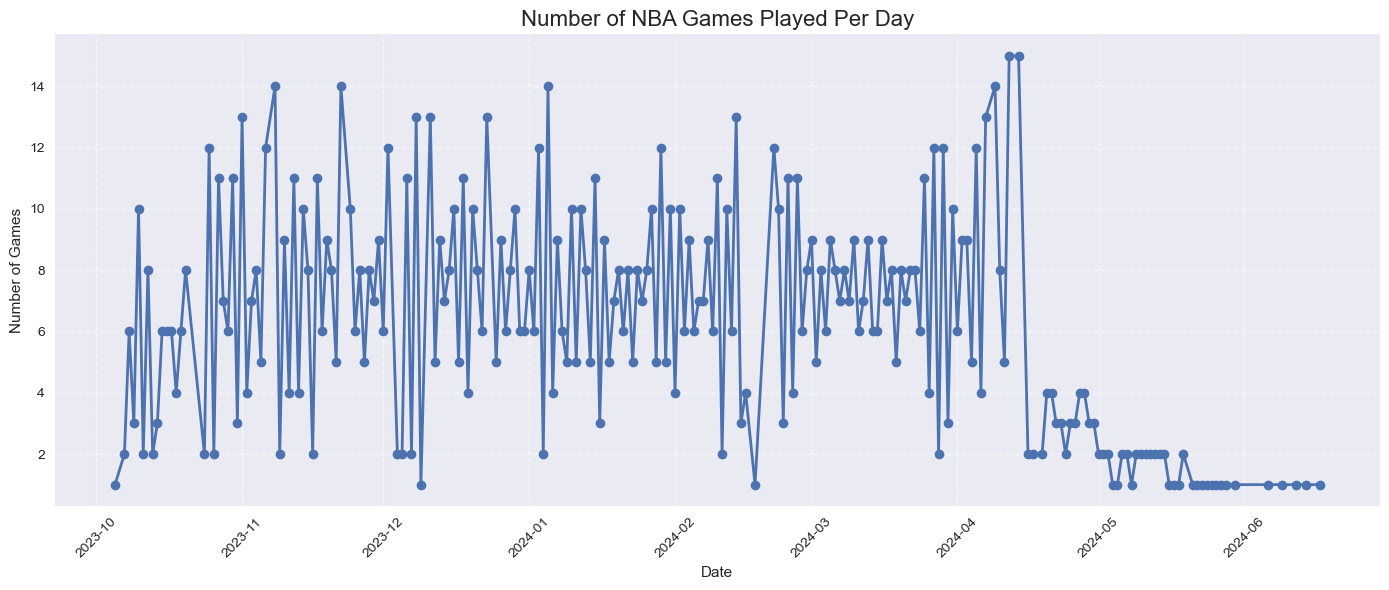

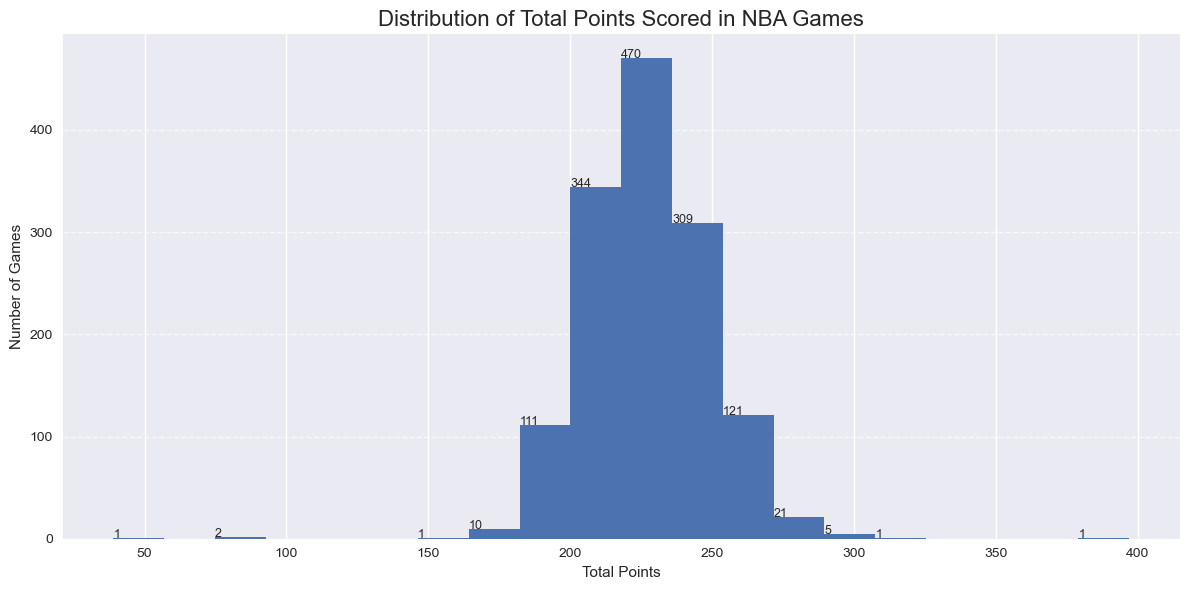

In [19]:
# 📈 VISUAL ANALYSIS (Improved Charts)

import matplotlib.ticker as ticker

# -----------------------------
# GRAPH 1: Games per day
# -----------------------------

games_per_day = analyzer.games_per_day()

plt.figure(figsize=(14,6))

plt.plot(games_per_day.index, games_per_day.values, marker="o", linewidth=2)

plt.title("Number of NBA Games Played Per Day", fontsize=16)

plt.xlabel("Date")
plt.ylabel("Number of Games")

# samo celobrojne vrednosti na Y osi
plt.gca().yaxis.set_major_locator(ticker.MaxNLocator(integer=True))

# grid za lakše čitanje
plt.grid(True, linestyle="--", alpha=0.6)

# rotacija datuma da se vide lepo
plt.xticks(rotation=45)

plt.tight_layout()
plt.show()


# -----------------------------
# GRAPH 2: Total points per game
# -----------------------------

totals = df.groupby('GAME_ID')['PTS'].sum()

plt.figure(figsize=(12,6))

counts, bins, patches = plt.hist(totals, bins=20)

plt.title("Distribution of Total Points Scored in NBA Games", fontsize=16)

plt.xlabel("Total Points")
plt.ylabel("Number of Games")

plt.grid(axis='y', linestyle='--', alpha=0.7)

# dodavanje broja iznad svake kolone
for count, bin_edge in zip(counts, bins):
    if count > 0:
        plt.text(bin_edge, count, int(count), fontsize=9)

plt.tight_layout()
plt.show()

In [11]:
# 📊 ANALYSIS QUESTIONS

print("Average total points per game:")
print(analyzer.average_total_points())

print("\nDay with most NBA games:")
print(analyzer.games_per_day().idxmax())

print("\nHighest scoring game:")
print(analyzer.highest_scoring_game())

print("\nLowest scoring game:")
print(analyzer.lowest_scoring_game())

home_avg, away_avg = analyzer.home_vs_away_average()

print("\nHome vs Away scoring:")
print("Home average:", home_avg)
print("Away average:", away_avg)

Average total points per game:
226.81961345740874

Day with most NBA games:
2024-04-12 00:00:00

Highest scoring game:
397

Lowest scoring game:
39

Home vs Away scoring:
Home average: 114.55579399141631
Away average: 112.18181818181819


In [12]:
# 📊 2D TABLE – TEAM SCORING

team_table = df.groupby("TEAM_NAME")["PTS"].mean().sort_values(ascending=False)

print("Average points scored by NBA teams")

display(team_table.to_frame().style
        .background_gradient(cmap='Greens')
        .set_caption("Average Points per Team"))

Average points scored by NBA teams


,PTS
TEAM_NAME,
East NBA All Stars East,211.000000
West NBA All Stars West,186.000000
Madrid Baloncesto,127.000000
Indiana Pacers,121.201923
Oklahoma City Thunder,118.618557
Boston Celtics,118.273585
Milwaukee Bucks,117.817204
Golden State Warriors,117.715909
Atlanta Hawks,117.704545


In [13]:
# 📊 PIVOT TABLE – HOME VS AWAY

df["HOME_AWAY"] = df["MATCHUP"].apply(lambda x: "HOME" if "vs." in x else "AWAY")

pivot = pd.pivot_table(
    df,
    values="PTS",
    index="TEAM_NAME",
    columns="HOME_AWAY",
    aggfunc="mean"
)

display(pivot.style
        .background_gradient(cmap='Oranges')
        .set_caption("Average Points: Home vs Away"))

HOME_AWAY,AWAY,HOME
TEAM_NAME,,
Atlanta Hawks,114.522727,120.886364
Boston Celtics,115.653846,120.796296
Brooklyn Nets,108.860465,112.930233
Cairns Taipans,87.500000,nan
Charlotte Hornets,104.860465,108.093023
Chicago Bulls,112.000000,112.088889
Cleveland Cavaliers,108.816327,112.591837
Dallas Mavericks,114.000000,116.169811
Denver Nuggets,110.520000,115.897959


/var/folders/k1/_v6pjcjj3z52f5ty2gv0hrmm0000gn/T/ipykernel_50210/581445729.py:29: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  colors_map = plt.cm.get_cmap('tab10', len(teams_list))


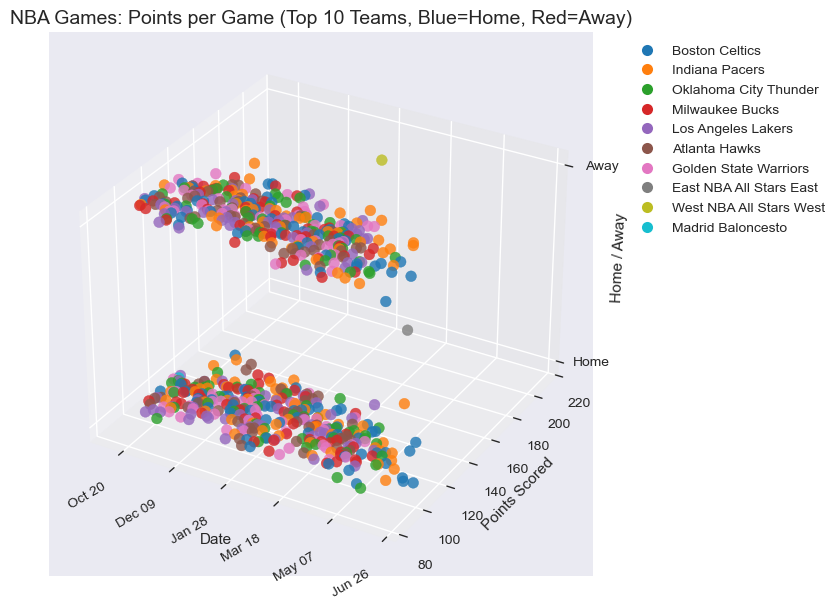

In [21]:
# 📊 3D Visualization – Simple and Clear

from mpl_toolkits.mplot3d import Axes3D
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import numpy as np

# Kreiramo kolonu HOME_AWAY
df['HOME_AWAY'] = df['MATCHUP'].apply(lambda x: 'Home' if 'vs.' in x else 'Away')

# Ako timova ima previše, uzimamo TOP 10 po proseku poena da graf bude čist
top_teams = df.groupby('TEAM_NAME')['PTS'].mean().sort_values(ascending=False).head(10).index
df_top = df[df['TEAM_NAME'].isin(top_teams)]

fig = plt.figure(figsize=(12,8))
ax = fig.add_subplot(111, projection='3d')

# X = datum
x = df_top['GAME_DATE'].map(pd.to_datetime).map(mdates.date2num)

# Y = poeni
y = df_top['PTS']

# Z = HOME / AWAY
z = df_top['HOME_AWAY'].map({'Home':0, 'Away':1})

# Boja = tim
teams_list = df_top['TEAM_NAME'].unique()
colors_map = plt.cm.get_cmap('tab10', len(teams_list))
color_dict = {team: colors_map(i) for i, team in enumerate(teams_list)}
colors = df_top['TEAM_NAME'].map(color_dict)

# Scatter plot
sc = ax.scatter(x, y, z, c=colors, s=60, alpha=0.8)

# Z osa → 0=Home, 1=Away
ax.set_zticks([0,1])
ax.set_zticklabels(['Home', 'Away'])

# Ose
ax.set_xlabel("Date")
ax.set_ylabel("Points Scored")
ax.set_zlabel("Home / Away")
ax.set_title("NBA Games: Points per Game (Top 10 Teams, Blue=Home, Red=Away)", fontsize=14)

# X osa format
ax.xaxis.set_major_formatter(mdates.DateFormatter('%b %d'))
fig.autofmt_xdate(rotation=30)

# Legenda timova
from matplotlib.lines import Line2D
legend_elements = [Line2D([0],[0], marker='o', color='w', label=team,
                          markerfacecolor=color_dict[team], markersize=8)
                   for team in teams_list]
ax.legend(handles=legend_elements, bbox_to_anchor=(1.05, 1), loc='upper left')

plt.show()

In [18]:
# 🔮 FUTURE SEASON STANDINGS PREDICTION (2026–2028)

teams = df.groupby("TEAM_NAME")

# win percentage iz postojeće sezone
wins = teams.apply(lambda x: (x["WL"] == "W").sum())
games = teams.size()

win_pct = wins / games

teams_list = win_pct.index

def simulate_season(season_year):

    predicted_wins = (win_pct * 82).round().astype(int)
    predicted_losses = 82 - predicted_wins

    table = pd.DataFrame({
        "Team": teams_list,
        "Predicted Wins": predicted_wins,
        "Predicted Losses": predicted_losses
    })

    table = table.sort_values("Predicted Wins", ascending=False)

    table["Position"] = range(1, len(table)+1)

    table = table[["Position","Team","Predicted Wins","Predicted Losses"]]

    print(f"\n==============================")
    print(f"Predicted NBA Standings – Season {season_year}")
    print(f"==============================")

    display(table)


# tabela za tri sezone
simulate_season(2026)
simulate_season(2027)
simulate_season(2028)


Predicted NBA Standings – Season 2026


/var/folders/k1/_v6pjcjj3z52f5ty2gv0hrmm0000gn/T/ipykernel_50210/3797604540.py:6: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  wins = teams.apply(lambda x: (x["WL"] == "W").sum())


,Position,Team,Predicted Wins,Predicted Losses
TEAM_NAME,,,,
Team Shannon,1,Team Shannon,82,0
Team Jalen,2,Team Jalen,82,0
Madrid Baloncesto,3,Madrid Baloncesto,82,0
East NBA All Stars East,4,East NBA All Stars East,82,0
Boston Celtics,5,Boston Celtics,65,17
Minnesota Timberwolves,6,Minnesota Timberwolves,56,26
Denver Nuggets,7,Denver Nuggets,55,27
Oklahoma City Thunder,8,Oklahoma City Thunder,55,27
LA Clippers,9,LA Clippers,49,33



Predicted NBA Standings – Season 2027


,Position,Team,Predicted Wins,Predicted Losses
TEAM_NAME,,,,
Team Shannon,1,Team Shannon,82,0
Team Jalen,2,Team Jalen,82,0
Madrid Baloncesto,3,Madrid Baloncesto,82,0
East NBA All Stars East,4,East NBA All Stars East,82,0
Boston Celtics,5,Boston Celtics,65,17
Minnesota Timberwolves,6,Minnesota Timberwolves,56,26
Denver Nuggets,7,Denver Nuggets,55,27
Oklahoma City Thunder,8,Oklahoma City Thunder,55,27
LA Clippers,9,LA Clippers,49,33



Predicted NBA Standings – Season 2028


,Position,Team,Predicted Wins,Predicted Losses
TEAM_NAME,,,,
Team Shannon,1,Team Shannon,82,0
Team Jalen,2,Team Jalen,82,0
Madrid Baloncesto,3,Madrid Baloncesto,82,0
East NBA All Stars East,4,East NBA All Stars East,82,0
Boston Celtics,5,Boston Celtics,65,17
Minnesota Timberwolves,6,Minnesota Timberwolves,56,26
Denver Nuggets,7,Denver Nuggets,55,27
Oklahoma City Thunder,8,Oklahoma City Thunder,55,27
LA Clippers,9,LA Clippers,49,33


In [ ]:
# napisi mi listu koja ce unutar liste da ima 4 liste svaka lista treba da ima 1 objekat 1 string 1 broj i 1 bulijen

In [261]:
lista = [
    ["aleksa", 2, {"car": "mercedes"}, True],
    ["slavko", 4, {"car": "audi"}, False],
    ["ari", 7, {"pas": "kokerspanijel"}, True],
    ["petar", 23, {"car": "bmw"}, False]
]



        
listaa = (1, 2, 4, 8, {"car": "mercedes"})
listaa[4]["car"] = "joca"
